Hands-On Lab: Training a Neural Network     
● Step 1: Build a Keras Sequential network appropriate for the Phase 3 project task (correct output layer and loss).        
● Step 2: Compile with Adam and the right loss, then train with a validation split for at least 30 epochs.      
● Step 3: Plot training vs. validation loss and accuracy from the history object and diagnose the fit.      
● Step 4: Add dropout and/or batch normalization and compare the new loss curves to the previous run.       
● Step 5: Evaluate on the test set and compare the score to the Day 1 baseline.     

#### Load, Clean & split data:

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split , cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score,recall_score, classification_report, confusion_matrix, f1_score

from sklearn.neural_network import MLPClassifier

In [6]:
df = pd.read_csv(r"C:\Users\Masters Computer\Desktop\VScode_For_ Python\internship\Sprint 1\Data\heart_disease.csv" )

In [7]:
print (df.shape,"\n")

print ("Null values: \n", df.isna().sum(),"\n")

print("duplicates :",df.duplicated().sum(),"\n")

(10000, 21) 

Null values: 
 Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI                       22
High Blood Pressure       26
Low HDL Cholesterol       25
High LDL Cholesterol      26
Alcohol Consumption     2586
Stress Level              22
Sleep Hours               25
Sugar Consumption         30
Triglyceride Level        26
Fasting Blood Sugar       22
CRP Level                 26
Homocysteine Level        20
Heart Disease Status       0
dtype: int64 

duplicates : 0 



In [8]:
print ("Information:")
df.info()

Information:
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Age                   9971 non-null   float64
 1   Gender                9981 non-null   str    
 2   Blood Pressure        9981 non-null   float64
 3   Cholesterol Level     9970 non-null   float64
 4   Exercise Habits       9975 non-null   str    
 5   Smoking               9975 non-null   str    
 6   Family Heart Disease  9979 non-null   str    
 7   Diabetes              9970 non-null   str    
 8   BMI                   9978 non-null   float64
 9   High Blood Pressure   9974 non-null   str    
 10  Low HDL Cholesterol   9975 non-null   str    
 11  High LDL Cholesterol  9974 non-null   str    
 12  Alcohol Consumption   7414 non-null   str    
 13  Stress Level          9978 non-null   str    
 14  Sleep Hours           9975 non-null   float64
 15  Sugar Consumption 

In [9]:
print (df.columns)

Index(['Age', 'Gender', 'Blood Pressure', 'Cholesterol Level',
       'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'BMI',
       'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol',
       'Alcohol Consumption', 'Stress Level', 'Sleep Hours',
       'Sugar Consumption', 'Triglyceride Level', 'Fasting Blood Sugar',
       'CRP Level', 'Homocysteine Level', 'Heart Disease Status'],
      dtype='str')


In [10]:
categorical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['str']).columns.tolist()

numerical_cols = df.drop(columns ='Heart Disease Status' ).select_dtypes(include=['int64','float64']).columns.tolist()

print("categorical columns name: ")
print(categorical_cols)

print("\nnumerical columns name: ")
print(numerical_cols)

categorical columns name: 
['Gender', 'Exercise Habits', 'Smoking', 'Family Heart Disease', 'Diabetes', 'High Blood Pressure', 'Low HDL Cholesterol', 'High LDL Cholesterol', 'Alcohol Consumption', 'Stress Level', 'Sugar Consumption']

numerical columns name: 
['Age', 'Blood Pressure', 'Cholesterol Level', 'BMI', 'Sleep Hours', 'Triglyceride Level', 'Fasting Blood Sugar', 'CRP Level', 'Homocysteine Level']


we have some missing values so we deal with them:   

- numeric: fill with median.    
- categorical: fill with mode.    

for Alcohol Consumption we rectify the data since none is a category rather than a null value.

In [11]:
print("Alcohol Consumption categories Before: ", df['Alcohol Consumption'].unique())

# numnerical 
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# categorical
for col in categorical_cols: 
    
    if col == "Alcohol Consumption":
        df[col] = df[col].fillna("Zero")
        
    else:
        df[col] = df[col].fillna(df[col].mode()[0])
    
    
print ("\nAlcohol Consumption categories After: ", df['Alcohol Consumption'].unique())
print ("\nNull values 'after': \n", df.isna().sum(),"\n")


Alcohol Consumption categories Before:  <StringArray>
['High', 'Medium', 'Low', nan]
Length: 4, dtype: str

Alcohol Consumption categories After:  <StringArray>
['High', 'Medium', 'Low', 'Zero']
Length: 4, dtype: str

Null values 'after': 
 Age                     0
Gender                  0
Blood Pressure          0
Cholesterol Level       0
Exercise Habits         0
Smoking                 0
Family Heart Disease    0
Diabetes                0
BMI                     0
High Blood Pressure     0
Low HDL Cholesterol     0
High LDL Cholesterol    0
Alcohol Consumption     0
Stress Level            0
Sleep Hours             0
Sugar Consumption       0
Triglyceride Level      0
Fasting Blood Sugar     0
CRP Level               0
Homocysteine Level      0
Heart Disease Status    0
dtype: int64 



#### Data Preprocessing & Spliting

The dataset contains both numerical and categorical features. Numerical features are standardized using StandardScaler, while categorical features are converted into numerical representations using one-hot encoding. After preprocessing, the original 20 input variables produce 36 model input features.

The target variable Heart Disease Status is encoded as No = 0 and Yes = 1 because the neural network requires numerical labels. The training and testing sets are kept separate, with 80% of the samples used for training and 20% for final testing.

**Note:**   
Keras does not directly consume the mixed dataframe with string categories the same way sklearn ColumnTransformer pipeline does.

So we should first transform the features using the existing preprocessor:

In [12]:
preprocessor = ColumnTransformer([("num",  StandardScaler(), numerical_cols)
                                 ,
                                ("col", OneHotEncoder(handle_unknown="ignore"),  categorical_cols)
                                 ])

In [13]:
X = df.drop(columns ='Heart Disease Status')
y = df['Heart Disease Status']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42, stratify= y)

print(y_train.unique(),"\n")
print(y_train.value_counts(),"\n")
print(y_train.dtype)

<StringArray>
['No', 'Yes']
Length: 2, dtype: str 

Heart Disease Status
No     6400
Yes    1600
Name: count, dtype: int64 

str


In [33]:
print("Main class Balance: ","\n")
print(y_train.value_counts(normalize = True))


Main class Balance:  

Heart Disease Status
No     0.8
Yes    0.2
Name: proportion, dtype: float64


In [ ]:
# process data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# then convert the labels 
y_train_nn = y_train.map({
                            "No": 0,
                            "Yes": 1
})

y_test_nn = y_test.map({
                             "No": 0,
                             "Yes": 1
})

After preprocessing, the number of input features:

In [15]:
n_features = X_train_processed.shape[1]

print("Number of processed features:", n_features)

Number of processed features: 36


### Tensor flow, keras models:

In [36]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import BatchNormalization, Dropout
from sklearn.utils.class_weight import compute_class_weight


#### Basic Model:

**Basic Neural Network Architecture**

The first neural network contains two hidden Dense layers with 64 and 32 neurons.   
 ReLU activation is used in the hidden layers because it provides a simple nonlinear transformation and is commonly effective for deep-learning models.     
  The output layer contains one neuron with sigmoid activation because this is a binary classification problem.         
   Sigmoid maps the output to a value between 0 and 1 representing the predicted probability of heart disease.      

##### model, compile and fit:

In [16]:
model = Sequential([
    tf.keras.Input(shape=(n_features,)),
    Dense(64, activation="relu"),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [17]:
# compile ( sets the optimizer, loss, and metrics)
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

**Model Compilation**

The Adam optimizer is used to update the network weights during backpropagation.        
 Binary cross-entropy is used as the loss function because the target contains two classes.     
  Accuracy is initially tracked as a performance metric, although additional metrics such as precision and recall are required because the dataset is imbalanced.   

In [18]:
# train ( runs the training loop)
history = model.fit(
    X_train_processed,
    y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7967 - loss: 0.5127 - val_accuracy: 0.8031 - val_loss: 0.5016
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7992 - loss: 0.4988 - val_accuracy: 0.8031 - val_loss: 0.5029
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7992 - loss: 0.4945 - val_accuracy: 0.8031 - val_loss: 0.5027
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7992 - loss: 0.4910 - val_accuracy: 0.8031 - val_loss: 0.5036
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7992 - loss: 0.4869 - val_accuracy: 0.8031 - val_loss: 0.5052
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7994 - loss: 0.4840 - val_accuracy: 0.8031 - val_loss: 0.5079
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7994 - loss: 0.4789 - val_accuracy: 0.8025 - val_loss: 0.5088
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7998 - loss: 0.4734 - val_accuracy: 0.

**Training Configuration**

The network is trained for 30 epochs using batches of 32 samples.       
 A validation split of 20% is used to monitor performance on data that is not used for weight updates.      
  Comparing training and validation metrics across epochs helps identify underfitting and overfitting.      

##### Plots:

- Training history plot:

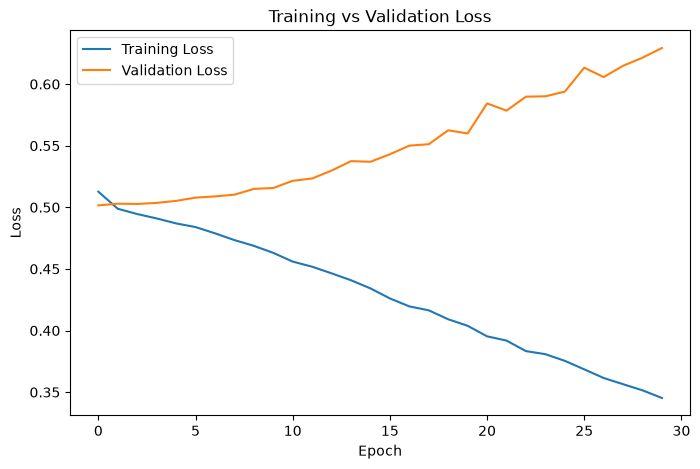

In [19]:

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

**Loss Curve Interpretation**

The training loss decreases continuously throughout training, showing that the neural network is learning patterns in the training data.        
 However, the validation loss stops improving early and gradually increases while the training loss continues to decrease.      
  This divergence indicates **`overfitting`**: the model is becoming increasingly fitted to the training samples without improving its ability to generalize to unseen validation data.

- Accuracy plot:

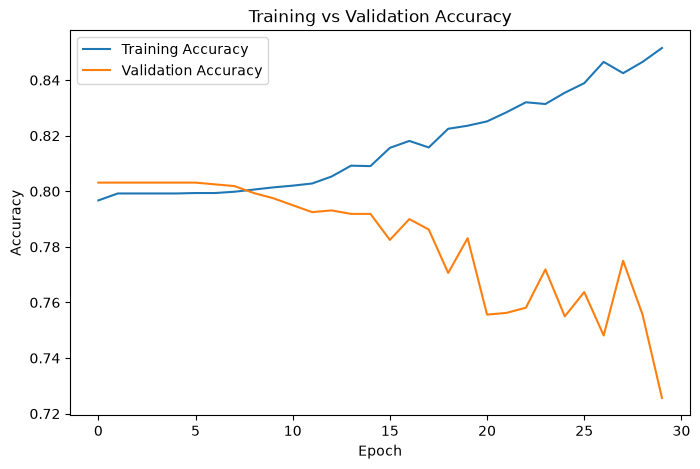

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

**Accuracy Curve Interpretation**

Training accuracy gradually increases during training, while validation accuracy remains close to 80% and later begins to decrease slightly.        
 Since approximately 80% of the dataset belongs to the No class, an accuracy near 80% can be achieved by strongly favoring the majority class.      
  Therefore, accuracy alone is not sufficient for evaluating this dataset.      
   The growing gap between training and validation performance also provides evidence of **`overfitting`**.

#### Regularized Model:

**Regularized Model**

Batch normalization and dropout were added to improve training stability and reduce overfitting.        
 Batch normalization normalizes intermediate activations during training,       
  while dropout randomly disables a fraction of neurons during each training step,      
   reducing reliance on individual neurons.

The regularized model shows more controlled training behavior compared with the original model.     
 **However**, precision and recall reveal a separate issue caused by `class imbalance`.     
  Recall for the positive (Yes) class decreases toward zero during training, while accuracy remains close to 80%.       
   This indicates that the model increasingly favors the majority No class rather than learning to identify heart-disease cases.        

##### model, compile and fit:

In [21]:
model_regularized = Sequential([
    tf.keras.Input(shape=(n_features,)),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

In [ ]:
# compile ( sets the optimizer, loss, and metrics)
model_regularized.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
        ]
)

In [23]:
# train (runs the training loop)
history_regularized = model_regularized.fit(
    X_train_processed,
    y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6380 - loss: 0.6784 - precision: 0.2045 - recall: 0.2778 - val_accuracy: 0.8031 - val_loss: 0.5238 - val_precision: 0.5000 - val_recall: 0.0032
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7633 - loss: 0.5538 - precision: 0.2167 - recall: 0.0685 - val_accuracy: 0.8031 - val_loss: 0.5091 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7842 - loss: 0.5299 - precision: 0.1883 - recall: 0.0226 - val_accuracy: 0.8031 - val_loss: 0.5075 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7953 - loss: 0.5164 - precision: 0.3810 - recall: 0.0311 - val_accuracy: 0.8031 - val_loss: 0.5068 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7958 - loss: 0.5128 - precision: 0.2609 - recall: 0.0093 - val_accurac

##### Plots:

- Training loss plot:

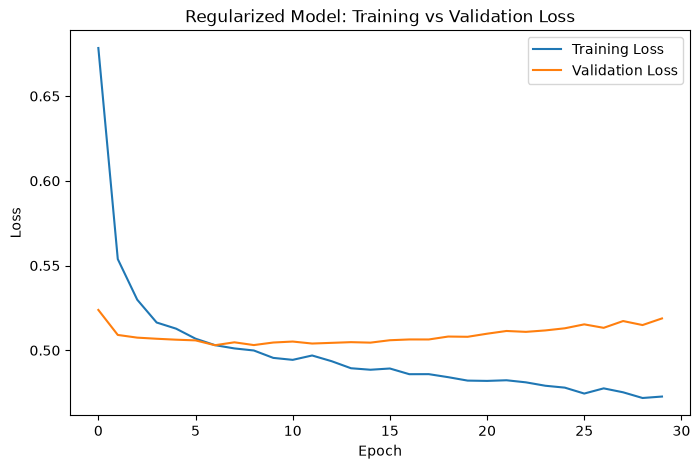

In [26]:
plt.figure(figsize=(8, 5))

plt.plot( history_regularized.history["loss"] , label="Training Loss")

plt.plot( history_regularized.history["val_loss"] , label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Regularized Model: Training vs Validation Loss")
plt.legend()

plt.show()

**Loss Curve Interpretation**

The training loss decreases during training, while the validation loss improves only slightly and then stays higher than the training loss.     
 This shows that regularization `reduces some of the overfitting` seen in the basic model, `but` the model `still does not generalize much better to unseen data`.

- Accuracy plot

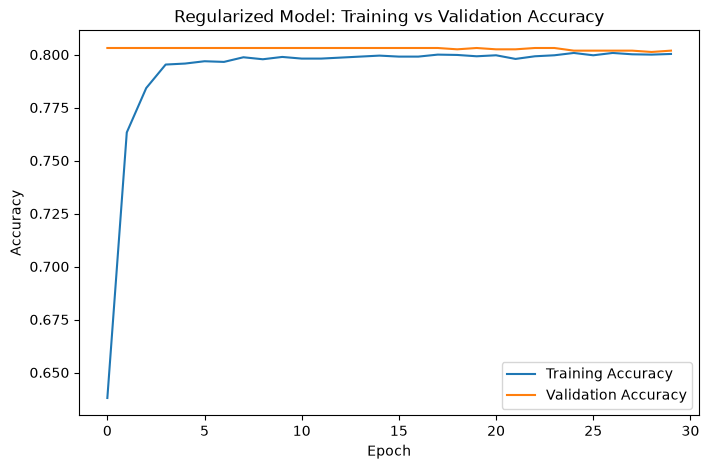

In [27]:
plt.figure(figsize=(8, 5))

plt.plot(history_regularized.history["accuracy"], label="Training Accuracy")
plt.plot(history_regularized.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Regularized Model: Training vs Validation Accuracy")

plt.legend()

plt.show()

**Accuracy Curve Interpretation**

The training and validation accuracy remain close to 80%.       
 `However`, because about 80% of the dataset belongs to the No class, `this accuracy is misleading`.        
  The model is mainly predicting the majority class instead of learning to detect heart-disease cases.      

##### Evaluation:

In [25]:
# evaluate (measures performance on the test set)

test_loss, test_accuracy, test_precision, test_recall = model_regularized.evaluate( X_test_processed, y_test_nn)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7980 - loss: 0.5231 - precision: 0.0000e+00 - recall: 0.0000e+00
Test Loss: 0.5230955481529236
Test Accuracy: 0.7979999780654907
Test Precision: 0.0
Test Recall: 0.0


**Test Evaluation**

The regularized model achieved approximately 79.8% test accuracy with a binary cross-entropy loss of approximately 0.523.        
 **However**, both `precision` and `recall` for the `positive class` were 0.      
  This means that the model failed to identify any positive heart-disease cases.        
   The high accuracy is therefore misleading because approximately 80% of the dataset belongs to the negative class.        
    This demonstrates why precision, recall, F1-score, and the confusion matrix are important when evaluating an imbalanced classification dataset.

In [28]:
y_prob = model_regularized.predict(X_test_processed)

y_pred = (y_prob >= 0.5).astype(int)

print(np.unique(y_pred, return_counts=True))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
(array([0, 1]), array([1996,    4]))


In [34]:
print(confusion_matrix(y_test_nn, y_pred))

print(classification_report(y_test_nn, y_pred, target_names=["No", "Yes"]))

print("Macro F1:", f1_score( y_test_nn,  y_pred, average="macro" ))

[[1596    4]
 [ 400    0]]
              precision    recall  f1-score   support

          No       0.80      1.00      0.89      1600
         Yes       0.00      0.00      0.00       400

    accuracy                           0.80      2000
   macro avg       0.40      0.50      0.44      2000
weighted avg       0.64      0.80      0.71      2000

Macro F1: 0.44382647385984425


#### Regularized Balanced Model: 

**Regularized Balanced Model**

The previous neural network achieved high accuracy but failed to identify the positive heart-disease class, mainly because the dataset is imbalanced.       
 Approximately 80% of the training samples belong to the No class and only 20% belong to the Yes class.     

To address this issue, class weighting is added during training.        
 Higher weight is assigned to the minority Yes class so that misclassifying a heart-disease case contributes more strongly to the loss.     
  The model architecture still uses batch normalization and dropout to reduce overfitting, while class weights are used specifically to address class imbalance.

##### Model, compile and fit:

In [ ]:
# first compute class weights from y_train_nn

classes = np.array([0, 1]) # positive & negative classes 

weights = compute_class_weight( class_weight = "balanced",  classes = classes,   y = y_train_nn)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.625), np.int64(1): np.float64(2.5)}


**Class weights** 

 {0 : 0.625 , 1 : 2.5}

Conceptually, instead of treating mistakes equally:

Wrong No prediction  → penalty 1        
Wrong Yes prediction → penalty 1        

we now have something roughly like:        

Wrong No prediction  → penalty 0.625        
Wrong Yes prediction → penalty 2.5      

In [40]:
model_balanced = Sequential([
    tf.keras.Input(shape=(n_features,)),

    Dense(64, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

In [41]:
# compile

model_balanced.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [42]:
# train (using the class weights obtained)

history_balanced = model_balanced.fit(
    X_train_processed,
    y_train_nn,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    class_weight=class_weights, # the important line
    verbose=1
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.5100 - loss: 0.7752 - precision: 0.2120 - recall: 0.5300 - val_accuracy: 0.4381 - val_loss: 0.7275 - val_precision: 0.1965 - val_recall: 0.6000
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5052 - loss: 0.7312 - precision: 0.2079 - recall: 0.5214 - val_accuracy: 0.4444 - val_loss: 0.7271 - val_precision: 0.1914 - val_recall: 0.5651
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5239 - loss: 0.7102 - precision: 0.2189 - recall: 0.5339 - val_accuracy: 0.4594 - val_loss: 0.7210 - val_precision: 0.1924 - val_recall: 0.5460
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5275 - loss: 0.7020 - precision: 0.2237 - recall: 0.5479 - val_accuracy: 0.4719 - val_loss: 0.7100 - val_precision: 0.2009 - val_recall: 0.5651
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5306 - loss: 0.6927 - precision: 0.2272 - recall: 0.5572 - val_accuracy: 0.4769 - val_loss: 0.

##### Plots:

- Training loss plot:

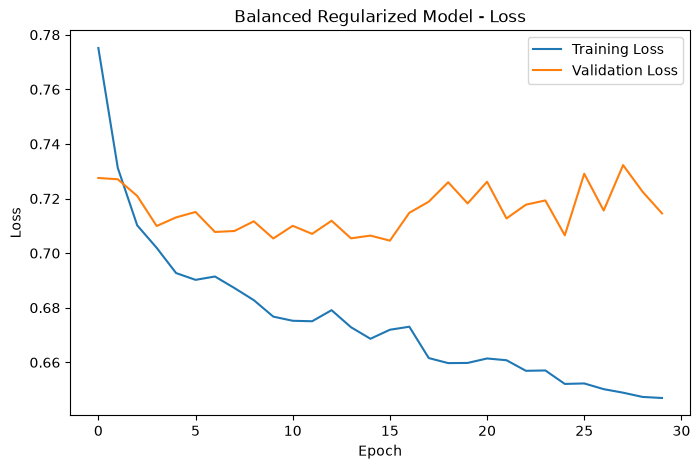

In [43]:

plt.figure(figsize=(8, 5))

plt.plot(history_balanced.history["loss"], label="Training Loss")

plt.plot(history_balanced.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Balanced Regularized Model - Loss")
plt.legend()

plt.show()

**Loss Interpretation**

After applying class weights, the `training and validation loss stay relatively close to each other`.       
 The model no longer focuses only on minimizing errors for the majority class.      
  However, `the loss remains fairly high`, showing that separating the two classes is still difficult for the model.  

- Accuracy plot:

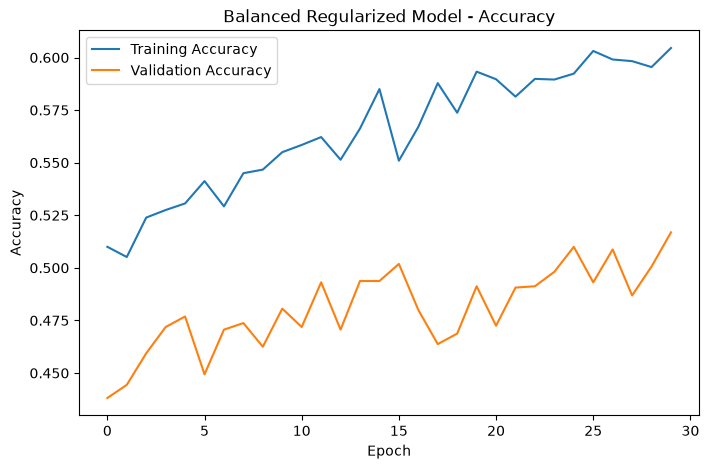

In [44]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_balanced.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history_balanced.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Balanced Regularized Model - Accuracy")
plt.legend()

plt.show()

**Accuracy Interpretation**

Accuracy decreases to around 50% after class weighting.     
 This is expected because the `model is no longer predicting mostly No`.      
  It now attempts to classify both classes more equally.        
   Therefore, the `lower accuracy does not automatically mean the model became worse`.

- Recall plot:

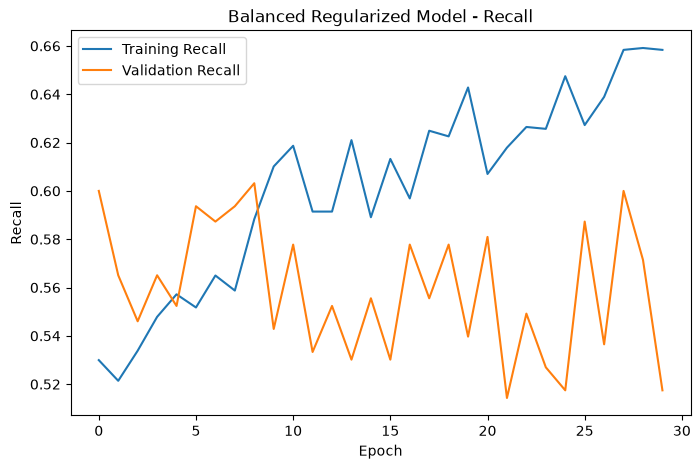

In [45]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_balanced.history["recall"],
    label="Training Recall"
)

plt.plot(
    history_balanced.history["val_recall"],
    label="Validation Recall"
)

plt.xlabel("Epoch")
plt.ylabel("Recall")
plt.title("Balanced Regularized Model - Recall")
plt.legend()

plt.show()

**Recall Curve Interpretation**

`Recall stays around 50%`, showing that the balanced model is now detecting a meaningful portion of the positive heart-disease cases.     
 This is a `major improvement over the previous model, where recall was 0`.       
  Class weighting successfully forces the model to pay more attention to the minority Yes class.

##### Evaluation:

In [46]:
results_balanced = model_balanced.evaluate(
    X_test_processed,
    y_test_nn,
    return_dict=True
)

print("Test Loss:", results_balanced["loss"])
print("Test Accuracy:", results_balanced["accuracy"])
print("Test Precision:", results_balanced["precision"])
print("Test Recall:", results_balanced["recall"])

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5175 - loss: 0.7124 - precision: 0.2073 - recall: 0.5000  
Test Loss: 0.7124247550964355
Test Accuracy: 0.5174999833106995
Test Precision: 0.20725388824939728
Test Recall: 0.5


In [47]:
y_prob_balanced = model_balanced.predict(X_test_processed)
y_pred_balanced = (y_prob_balanced >= 0.5).astype(int).ravel()



print("Confusion Matrix:")
print(confusion_matrix(y_test_nn, y_pred_balanced))

print("\nClassification Report:")
print( classification_report( y_test_nn, y_pred_balanced, target_names=["No", "Yes"]) )

print("Macro F1:" , f1_score(y_test_nn, y_pred_balanced, average="macro") )

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Confusion Matrix:
[[835 765]
 [200 200]]

Classification Report:
              precision    recall  f1-score   support

          No       0.81      0.52      0.63      1600
         Yes       0.21      0.50      0.29       400

    accuracy                           0.52      2000
   macro avg       0.51      0.51      0.46      2000
weighted avg       0.69      0.52      0.57      2000

Macro F1: 0.4634081920609435


**Evaluation interpetaion**     

The balanced model `achieved lower accuracy than the previous model`,     
 `but` its positive-class `recall improved from 0 to 0.50` and its macro `F1-score improved from approximately 0.44 to 0.46`.     
  This shows that **`class weighting reduced the majority-class bias`** and allowed the model to detect heart-disease cases.      
   However, precision remains low because the model also produces many false-positive predictions.      

The goal of the balanced model is not necessarily to increase accuracy.     
 Instead, the goal is to improve recall and F1-score for the minority positive class.           
  A reduction in overall accuracy can therefore be acceptable if the model begins identifying substantially more heart-disease cases.   


#### Models small overview: 

**Basic model**: overfits and favors the majority class.

**Regularized model**: regularization reduces overfitting somewhat, but it still predicts almost everything as No.

**Regularized + balanced model**: class weighting fixes the zero-recall problem, increasing positive recall to 0.50, but at the cost of many false positives and lower accuracy.